In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import pandas as pd
df=pd.read_csv('/content/Restaurant_Reviews.csv')
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good. ## $%,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize

def preprocess_text(s):
  s=s.lower()
  s=re.sub('[^a-z]'," ",s)
  tokens=word_tokenize(s)
  stop_words=set(stopwords.words('english'))
  stop_words.discard('not')
  stop_words.discard('no')
  stop_words.discard('bad')
  stop_words.discard('never')

  filtered_tokens=[i for i in tokens if i not in stop_words]
  return ' '.join(filtered_tokens)

In [ ]:
df['Clean_Review']=df['Review'].apply(preprocess_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
x_pre=tfidf.fit_transform(df['Clean_Review']).toarray()

In [ ]:
x_pre.shape

(1000, 1888)

In [ ]:
Y=df['Liked']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_pre,Y,test_size=0.1,random_state=21)

In [ ]:
x_train.shape

(900, 1888)

In [ ]:
x_test.shape

(100, 1888)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Input
from keras.callbacks import EarlyStopping

In [ ]:
model=Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(1000,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(200,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [ ]:
es=EarlyStopping(patience=20)
hist=model.fit(x_train,y_train,epochs=50,batch_size=16,validation_split=0.2,callbacks=[es])

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6208 - loss: 0.6744 - val_accuracy: 0.6778 - val_loss: 0.6451
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9083 - loss: 0.4028 - val_accuracy: 0.7389 - val_loss: 0.4533
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9764 - loss: 0.0951 - val_accuracy: 0.7333 - val_loss: 0.5937
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0287 - val_accuracy: 0.7500 - val_loss: 0.6301
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0182 - val_accuracy: 0.7333 - val_loss: 0.6981
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9958 - loss: 0.0184 - val_accuracy: 0.7056 - val_loss: 0.9096
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.7333 - val_loss: 0.7610
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0200 - val_accuracy: 0.7333 - val_loss

In [ ]:
model.evaluate(x_train,y_train)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9389 - loss: 0.1940


[0.19397929310798645, 0.9388889074325562]

In [ ]:
model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7700 - loss: 0.6552 


[0.6551563143730164, 0.7699999809265137]

In [ ]:
yprob_train=model.predict(x_train)
yprob_test=model.predict(x_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [ ]:
ypred_train=[1 if prob>0.5 else 0 for prob in yprob_train]
ypred_test=[1 if prob>0.5 else 0 for prob in yprob_test]

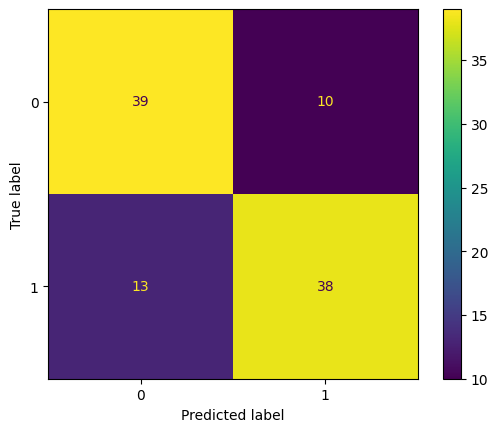

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,ypred_test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,ypred_test))

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        49
           1       0.79      0.75      0.77        51

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [ ]:
model.save('sentimentModel.keras')

In [ ]:
from keras.models import load_model

In [ ]:
rnn = load_model('/content/sentimentModel.keras')

In [ ]:
def predict_sentiment():
  text = input("Please enter restuaraunt review : ")
  text = preprocess_text(text)
  text_pre = tfidf.transform([text]).toarray()
  prob = rnn.predict(text_pre)
  if prob>=0.5:
    print("Positive Review")
  else:
    print("Negative Review")
  return prob

In [ ]:
predict_sentiment()

Please enter restuaraunt review : good food
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
Positive Review


array([[0.6130367]], dtype=float32)

In [ ]:
predict_sentiment()

Please enter restuaraunt review : bad food
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Negative Review


array([[4.657942e-05]], dtype=float32)